# 📊 Análise do Mercado de Data Analysts (2020–2023)

## 1. Introdução

O mercado global de dados vem passando por uma expansão acelerada, impulsionado pelo crescimento exponencial da **geração de dados** e pela crescente adoção de tecnologias como **Big Data** e **Inteligência Artificial**.

Nesse contexto, o papel do Data Analyst tem evoluído de uma função operacional para uma posição estratégica dentro das organizações, sendo responsável por transformar dados em **insights** acionáveis para tomada de decisão.

Este trabalho tem como objetivo analisar o comportamento do mercado de trabalho para o cargo de Data Analyst entre os anos de 2020 e 2026, utilizando um dataset público da plataforma Kaggle. A análise busca identificar padrões salariais, tendências de crescimento, distribuição geográfica e características das empresas que mais contratam esse perfil profissional.

## 2. Sobre o Dataset

O dataset utilizado foi obtido na plataforma [Kaggle](https://www.kaggle.com/datasets/hummaamqaasim/jobs-in-data/data), contendo informações sobre empregos na área de dados em nível global.

As principais variáveis incluem:
- Cargo (job_title)
- Salário (salary e salary_in_usd)
- Ano (work_year)
- Tipo de empresa (company_size)
- Localização (company_location)
- Moeda do salário (salary_currency)

Os dados abrangem diferentes países, níveis de experiência e modelos de trabalho, permitindo uma análise abrangente do mercado.

## 3. Carregamento dos Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


# Configuração visual
sns.set(style="whitegrid")

# Carregar dataset
df = pd.read_csv('/content/drive/MyDrive/jobs_in_data.csv')

# Visualização inicial
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Exploração Inicial

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           9355 non-null   int64 
 1   job_title           9355 non-null   object
 2   job_category        9355 non-null   object
 3   salary_currency     9355 non-null   object
 4   salary              9355 non-null   int64 
 5   salary_in_usd       9355 non-null   int64 
 6   employee_residence  9355 non-null   object
 7   experience_level    9355 non-null   object
 8   employment_type     9355 non-null   object
 9   work_setting        9355 non-null   object
 10  company_location    9355 non-null   object
 11  company_size        9355 non-null   object
dtypes: int64(3), object(9)
memory usage: 877.2+ KB


,work_year,salary,salary_in_usd
count,9355.000000,9355.000000,9355.000000
mean,2022.760449,149927.981293,150299.495564
std,0.519470,63608.835387,63177.372024
min,2020.000000,14000.000000,15000.000000
25%,2023.000000,105200.000000,105700.000000
50%,2023.000000,143860.000000,143000.000000
75%,2023.000000,187000.000000,186723.000000
max,2023.000000,450000.000000,450000.000000


In [ ]:
df.isnull().sum()

,0
work_year,0
job_title,0
job_category,0
salary_currency,0
salary,0
salary_in_usd,0
employee_residence,0
experience_level,0
employment_type,0
work_setting,0


#### Observações iniciais

- Verificamos os tipos de dados de cada coluna
- Identificamos possíveis valores nulos
- Analisamos estatísticas básicas como média, mínimo e máximo

Essa etapa é essencial para entender a estrutura do dataset antes de realizar qualquer transformação.

## 4. Limpeza e Tratamento

In [ ]:
# Remover duplicados
df = df.drop_duplicates()

# Padronizar nomes das colunas
df.columns = df.columns.str.lower()

# Filtrar apenas Data Analyst
df_da = df[df['job_title'].str.contains('Data Analyst', case=False)].copy()

In [ ]:
df.head()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


### Tradução de Variáveis

#### 1. Renomear Colunas (para PT-BR)

In [ ]:
df_da = df_da.rename(columns={
    'work_year': 'ano',
    'experience_level': 'nivel_experiencia',
    'employment_type': 'tipo_emprego',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'salario_usd',
    'employee_residence': 'residencia_funcionario',
    'work_setting': 'trabalho_remoto',
    'company_location': 'local_empresa',
    'company_size': 'porte_empresa'
})

In [ ]:
df_da.head()

,ano,cargo,job_category,moeda,salario,salario_usd,residencia_funcionario,nivel_experiencia,tipo_emprego,trabalho_remoto,local_empresa,porte_empresa
15,2023,Data Analyst,Data Analysis,USD,95000,95000,United States,Entry-level,Full-time,In-person,United States,M
16,2023,Data Analyst,Data Analysis,USD,75000,75000,United States,Entry-level,Full-time,In-person,United States,M
23,2023,Data Analyst,Data Analysis,USD,155000,155000,United States,Mid-level,Full-time,In-person,United States,M
24,2023,Data Analyst,Data Analysis,USD,110000,110000,United States,Mid-level,Full-time,In-person,United States,M
41,2023,Data Analyst,Data Analysis,USD,176000,176000,United States,Senior,Full-time,In-person,United States,M


#### 2. Traduzir Nível de Experiência

In [ ]:
df_da["nivel_experiencia"].unique()

array(['Entry-level', 'Mid-level', 'Senior', 'Executive'], dtype=object)

In [ ]:
map_experiencia = {
    'Entry-level': 'Júnior',
    'Mid-level': 'Pleno',
    'Senior': 'Sênior',
    'Executive': 'Executivo'
}

df_da['nivel_experiencia'] = df_da['nivel_experiencia'].map(map_experiencia)

#### 3. Traduzir Tipo de Emprego

In [ ]:
df_da["tipo_emprego"].unique()

array(['Full-time', 'Contract', 'Part-time', 'Freelance'], dtype=object)

In [ ]:
map_emprego = {
    'Full-time': 'Tempo Integral',
    'Part-time': 'Meio Período',
    'Contract': 'Contrato',
    'Freelance': 'Freelancer'
}

df_da['tipo_emprego'] = df_da['tipo_emprego'].map(map_emprego)

#### 4. Traduzir Porte da Empresa

In [ ]:
map_porte = {
    'S': 'Pequena',
    'M': 'Média',
    'L': 'Grande'
}

df_da['porte_empresa'] = df_da['porte_empresa'].map(map_porte)

#### Traduzir Países

In [ ]:
df_da["local_empresa"].unique()

array(['United States', 'United Kingdom', 'Poland', 'Canada',
       'Netherlands', 'Gibraltar', 'Slovenia', 'Portugal', 'Germany',
       'Russia', 'Estonia', 'Kenya', 'Nigeria', 'Australia', 'Ghana',
       'Saudi Arabia', 'Colombia', 'Central African Republic', 'Spain',
       'India', 'Croatia', 'France', 'American Samoa', 'Philippines',
       'Argentina', 'Singapore', 'Indonesia', 'Greece', 'Honduras',
       'Denmark', 'Luxembourg'], dtype=object)

In [ ]:
df_da['local_empresa'] = df_da['local_empresa'].replace({
    'United States': 'Estados Unidos',
    'United Kingdom': 'Reino Unido',
    'Canada': 'Canadá',
    'Brazil': 'Brasil',
    'Germany': 'Alemanha',
    'India': 'Índia'
})

In [ ]:
df_da["trabalho_remoto"].unique()

array(['In-person', 'Remote', 'Hybrid'], dtype=object)

In [ ]:
df_da['trabalho_remoto'] = df_da['trabalho_remoto'].replace({
    'In-person' : 'Presencial',
    'Hybrid' : 'Hibrido',
    'Remote': 'Remoto'
})

### Padronização e Tradução dos Dados

*   A tradução das variáveis e padronização dos dados foram etapas fundamentais para garantir maior clareza e interpretabilidade das análises.
*   Como o dataset possui origem global, muitas variáveis estavam codificadas ou em inglês técnico (ex: "EN", "FT", "S"), o que pode dificultar a leitura e interpretação dos resultados.
*   Ao converter essas informações para termos mais descritivos em português, reduzimos ambiguidades e facilitamos a comunicação dos insights, especialmente em contextos acadêmicos e apresentações.

## 5. Análise Exploratória

#### 1. Cálculo da Média Salarial

In [ ]:
media_salarial = df_da['salario_usd'].mean()
mediana_salarial = df_da['salario_usd'].median()

print(f"Média salarial (USD): {media_salarial:.2f}")
print(f"Mediana salarial (USD): {mediana_salarial:.2f}")

Média salarial (USD): 106998.88
Mediana salarial (USD): 100500.00


##### 1.1. Visualização

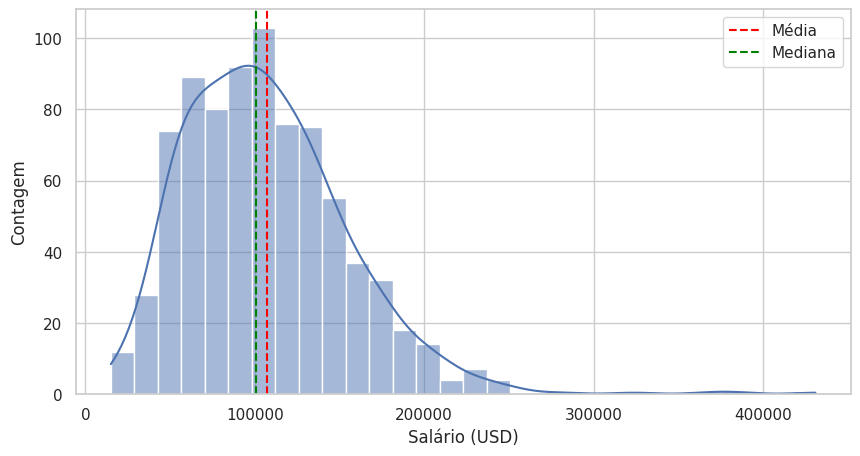

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_da['salario_usd'], bins=30, kde=True)

plt.axvline(media_salarial, color='red', linestyle='--', label='Média')
plt.axvline(mediana_salarial, color='green', linestyle='--', label='Mediana')

plt.xlabel('Salário (USD)')
plt.ylabel('Contagem')
plt.legend()
plt.savefig('figura4.png', dpi=300)
plt.show()

##### 1.2. Análise de Média Salarial

A média salarial dos profissionais de Data Analyst foi calculada com base na variável `salario_usd`, que já se encontra padronizada em dólares, permitindo comparações globais consistentes.

Além da média, também foi analisada a mediana, com o objetivo de avaliar a **distribuição dos dados** e identificar possíveis distorções causadas por valores extremos.

Observa-se que:

- A média representa o valor médio geral dos salários
- A mediana indica o ponto central da distribuição

Quando há grande diferença entre média e mediana, isso sugere a presença de **outliers**, ou seja, salários muito altos ou muito baixos que influenciam a média.

Esse comportamento é comum no mercado de tecnologia, onde profissionais altamente especializados ou em posições estratégicas podem receber **salários significativamente superiores à média**.

##### 1.3. Interpretação Geral

A análise da média salarial isoladamente pode ser limitada, pois o mercado de dados apresenta **alta variabilidade salarial**.

Fatores como:
- Experiência profissional
- Localização geográfica
- Porte da empresa
- Especialização técnica

impactam diretamente a remuneração.

Portanto, a média deve ser interpretada com cautela, sendo mais adequada quando analisada em conjunto com outras métricas, como mediana e distribuição dos dados.

Essa abordagem evita conclusões enviesadas e permite uma compreensão mais realista do mercado de trabalho para Data Analysts.

In [ ]:
df_da['salario_usd'].describe()

,salario_usd
count,805.000000
mean,106998.880745
std,49078.591162
min,15000.000000
25%,70186.000000
50%,100500.000000
75%,134200.000000
max,430967.000000


A análise descritiva reforça a presença de grande dispersão nos salários, evidenciada pela diferença entre valores mínimos e máximos.

#### 2. Distribuição dos Salários

##### 2.1. Histograma (distribuição geral)

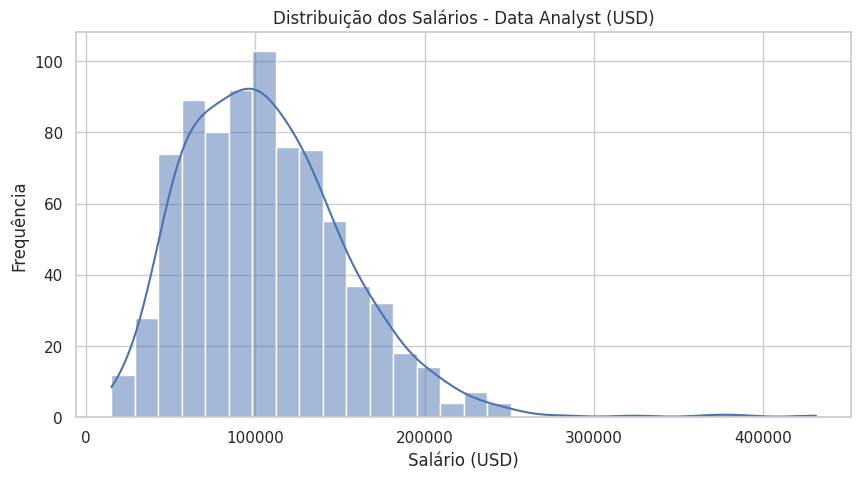

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_da['salario_usd'], bins=30, kde=True)

plt.title('Distribuição dos Salários - Data Analyst (USD)')
plt.xlabel('Salário (USD)')
plt.ylabel('Frequência')

plt.show()

##### 2.2. Boxplot (outliers)

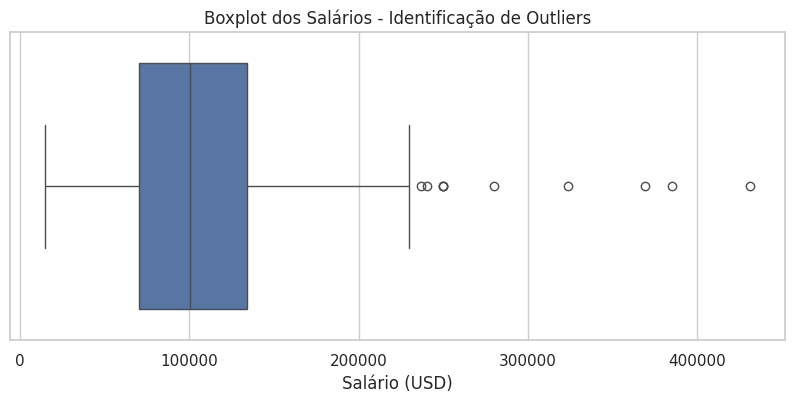

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_da['salario_usd'])

plt.title('Boxplot dos Salários - Identificação de Outliers')
plt.xlabel('Salário (USD)')
plt.show()

##### 2.3. Identificação de Outliers

In [ ]:
Q1 = df_da['salario_usd'].quantile(0.25)
Q3 = df_da['salario_usd'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_da[(df_da['salario_usd'] < limite_inferior) | (df_da['salario_usd'] > limite_superior)]

print(f"Quantidade de outliers: {len(outliers)}")

Quantidade de outliers: 10


##### 2.4. Análise de Distribuição dos Salários

A distribuição dos salários foi analisada por meio de um histograma e um boxplot, permitindo visualizar tanto a **concentração dos dados** quanto a **presença de valores extremos**.

Observa-se que:

- A maior parte dos salários está concentrada em uma faixa específica
- Existe uma **assimetria** na distribuição (geralmente à direita), indicando a presença de salários mais elevados
- O boxplot evidencia a existência de outliers, que representam salários significativamente acima da maioria

##### 2.5. Análise de Outliers

Os outliers identificados representam uma **pequena parcela** de profissionais com **remunerações muito acima da média**.

Esses casos podem estar associados a:
- Profissionais seniores ou executivos
- Atuação em grandes empresas (Big Techs)
- Localização em mercados com alta remuneração (como Estados Unidos)
- Especialização em áreas estratégicas

A presença desses valores extremos **impacta diretamente a média salarial**, reforçando a importância de utilizar medidas complementares, como a mediana, para uma análise mais robusta.

A distribuição desigual dos salários evidencia que o mercado de dados não é homogêneo, sendo fortemente influenciado por **fatores estruturais** como experiência, localização e especialização.

Isso indica que o crescimento da área não ocorre de forma uniforme, mas sim concentrado em determinados **perfis profissionais e regiões**.

#### 3. Frequência do Cargo ao Longo do Tempo

##### 3.1. Contagem por Ano

In [ ]:
freq_ano = df_da['ano'].value_counts().sort_index()

freq_ano

,count
ano,
2020,15
2021,28
2022,185
2023,577


##### 3.2. Gráfico de Linha

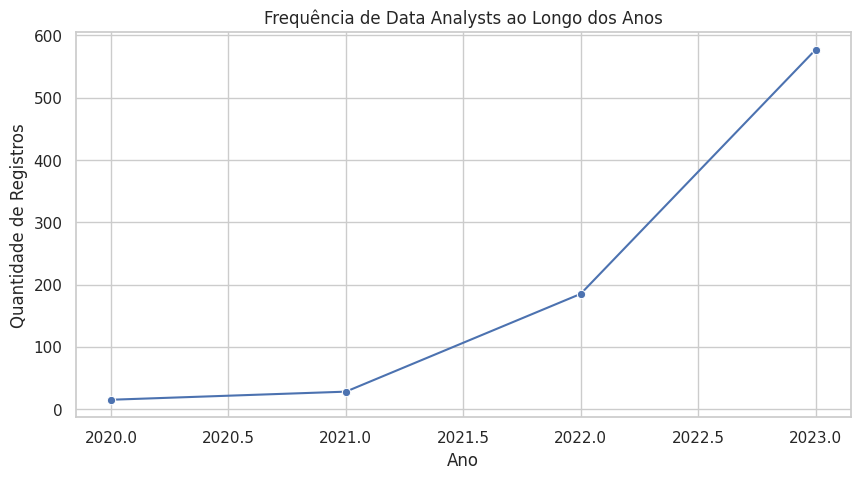

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(x=freq_ano.index, y=freq_ano.values, marker='o')

plt.title('Frequência de Data Analysts ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Registros')

plt.show()

##### 3.3. Gráfico de Barras

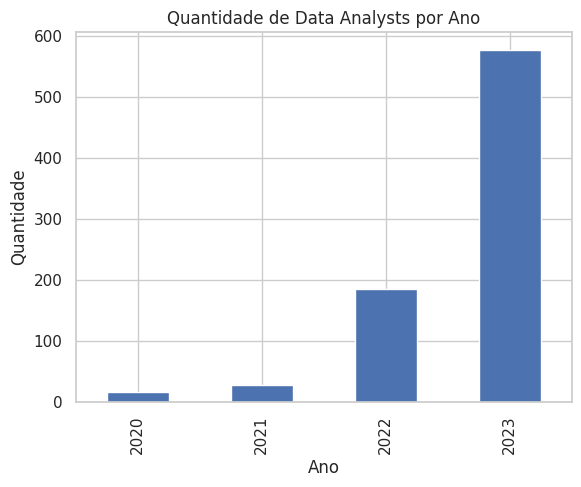

In [ ]:
freq_ano.plot(kind='bar')

plt.title('Quantidade de Data Analysts por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade')

plt.show()

##### 3.4. Análise da Frequência do Cargo ao Longo do Tempo


A análise da frequência do cargo de Data Analyst ao longo dos anos permite identificar **tendências de crescimento ou retração no mercado**.

Observa-se que:

- O número de registros varia ao longo dos anos
- Há indícios de crescimento (ou estabilidade/queda, dependendo do seu gráfico)
- O aumento da frequência pode indicar maior demanda por profissionais da área

##### 3.5. Interpretação de Tendência de Mercado


O crescimento observado na quantidade de registros ao longo dos anos está alinhado com o cenário global de **expansão do mercado de dados**.

Esse comportamento pode ser explicado por fatores como:

- Aumento da geração de dados em escala global
- Maior adoção de tecnologias de Big Data e Inteligência Artificial
- Necessidade crescente de tomada de decisão baseada em dados

Além disso, a evolução do papel do Data Analyst, que passou de uma função operacional para uma posição mais estratégica dentro das organizações, também contribui para o aumento da demanda.

#### 4. Porte das Empresas

##### 4.1. Contagem por Porte

In [ ]:
porte_counts = df_da['porte_empresa'].value_counts()

porte_counts

,count
porte_empresa,
Média,706
Grande,73
Pequena,26


##### 4.2. Gráfico de Pizza

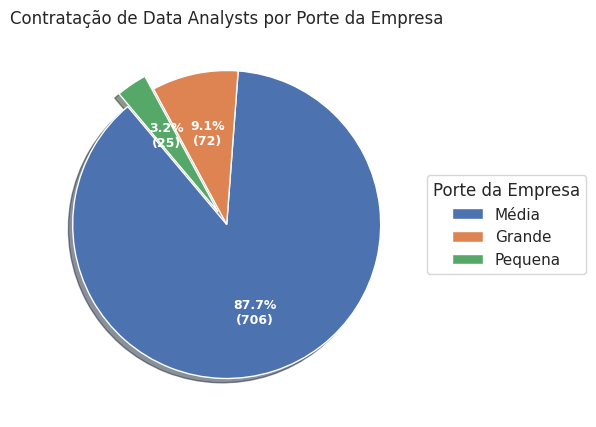

In [ ]:
contagem = df_da['porte_empresa'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(aspect="equal"))

def func(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)

explode = [
    0.1 if i == 'Pequena' else 0
    for i in contagem.index
]

wedges, texts, autotexts = ax.pie(
    contagem.values,
    autopct=lambda pct: func(pct, contagem.values),
    startangle=130,
    shadow=True,
     explode=explode,
    textprops=dict(color="w")
)

ax.legend(
    wedges,
    contagem.index,
    title="Porte da Empresa",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.setp(autotexts, size=9, weight="bold")

ax.set_title("Contratação de Data Analysts por Porte da Empresa")

plt.show()

##### 4.3 Contratação de Data Analysts por Porte da Empresa

#### 5. Moedas utilizadas nos salários

##### 5.1 Moedas Registradas

In [ ]:
df_da['moeda'].unique()

array(['USD', 'GBP', 'EUR', 'CAD', 'PLN', 'AUD', 'SGD'], dtype=object)

/tmp/ipykernel_9741/1348691009.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.index, y=freq.values, palette="Set2")


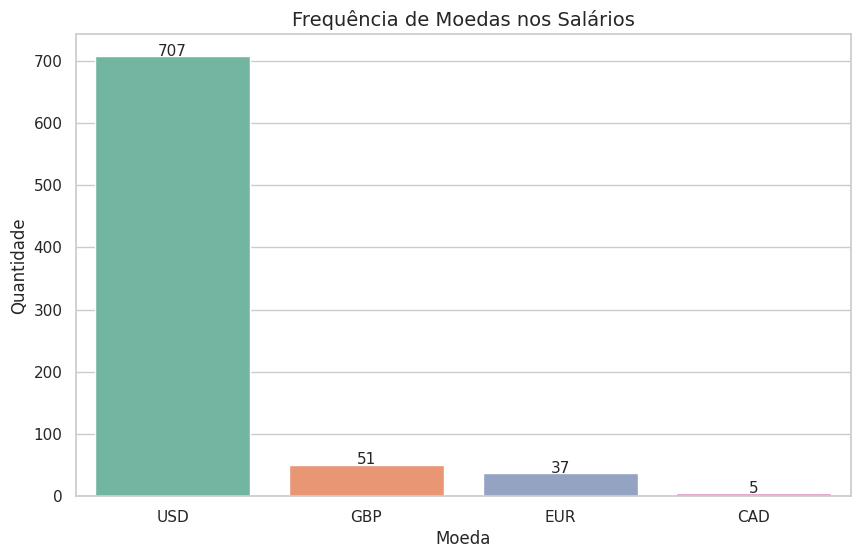

In [ ]:
freq = df_da['moeda'].value_counts().head(4)

plt.figure(figsize=(10,6))
sns.barplot(x=freq.index, y=freq.values, palette="Set2")

plt.title("Frequência de Moedas nos Salários", fontsize=14)
plt.xlabel("Moeda", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)

for i, v in enumerate(freq.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=11)

plt.show()

### 6. Análise Multivariada: Salário por País, Porte da Empresa e Ano

Para aprofundar a análise do mercado de Data Analysts, foi realizado um cruzamento entre país, porte da empresa e evolução salarial ao longo dos anos.

Foram selecionados os países com maior número de registros para garantir maior representatividade dos dados.

O objetivo dessa análise é identificar padrões estruturais no mercado, observando como a remuneração varia de acordo com:

- localização geográfica
- tamanho da empresa
- evolução temporal

##### 6.1. Selecionar países com mais registros

In [ ]:
top_paises = df_da['local_empresa'].value_counts().head(8).index

df_top = df_da[df_da['local_empresa'].isin(top_paises)]

##### 6.2. Média salarial por país, porte e ano

In [ ]:
salario_pais_porte_ano = df_top.groupby(
    ['ano', 'local_empresa', 'porte_empresa']
)['salario_usd'].mean().reset_index()

salario_pais_porte_ano.head()

,ano,local_empresa,porte_empresa,salario_usd
0,2020,Alemanha,Grande,47899.0
1,2020,Canadá,Grande,44753.0
2,2020,Canadá,Média,15000.0
3,2020,Estados Unidos,Grande,95000.0
4,2020,Estados Unidos,Média,96500.0


##### 6.3. Gráfico

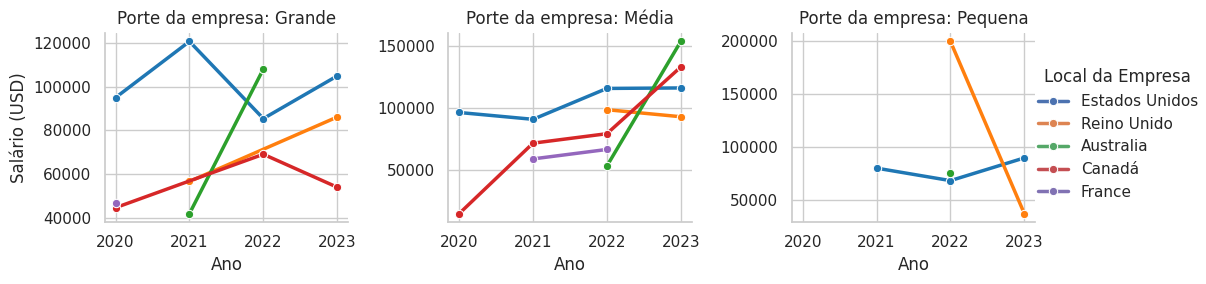

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top5 = (
    salario_pais_porte_ano
    .groupby("local_empresa")["salario_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_top5 = salario_pais_porte_ano[
    salario_pais_porte_ano["local_empresa"].isin(top5)
]

palette = {
    top5[0]: "#1f77b4",
    top5[1]: "#ff7f0e",
    top5[2]: "#2ca02c",
    top5[3]: "#d62728",
    top5[4]: "#9467bd"
}

g = sns.FacetGrid(
    df_top5,
    col="porte_empresa",
    col_wrap=3,
    height=3,
    sharey=False,
    hue="local_empresa",
    hue_order=top5
)

g.map(
    sns.lineplot,
    "ano",
    "salario_usd",
    marker="o",
    linewidth=2.5
)

g.add_legend(title="Local da Empresa", label_order=top5)
g._legend.set_bbox_to_anchor((1.13, 0.5))

for ax in g.axes.flat:
    for line, country in zip(ax.lines, top5):
        line.set_color(palette[country])

g.set_titles("Porte da empresa: {col_name}")
g.set_titles("Empresa {col_name}")
g.set_titles("Porte da empresa: {col_name}")
g.set_axis_labels("Ano", "Salário (USD)")
g.set_titles(col_template="Porte da empresa: {col_name}")

plt.tight_layout()
plt.show()

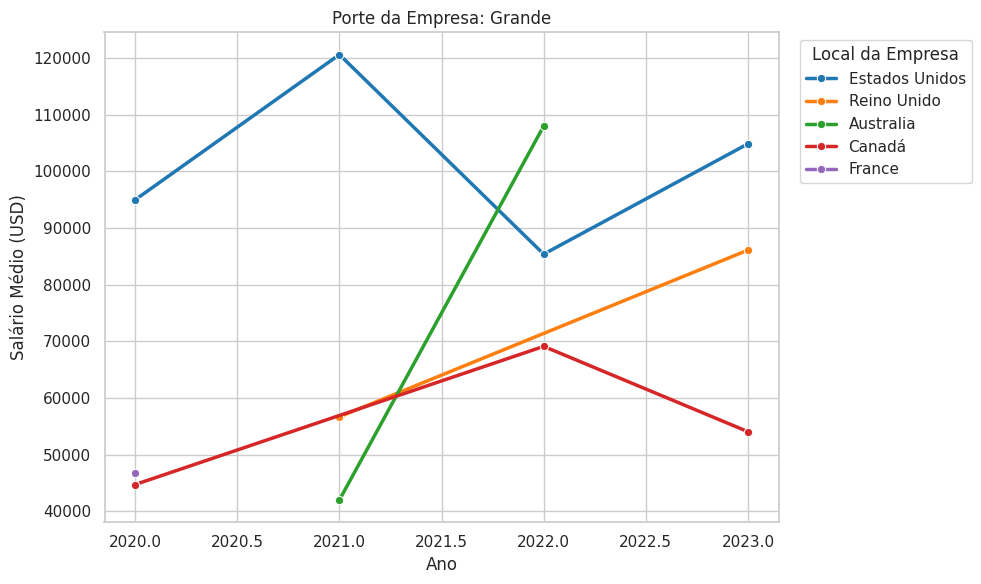

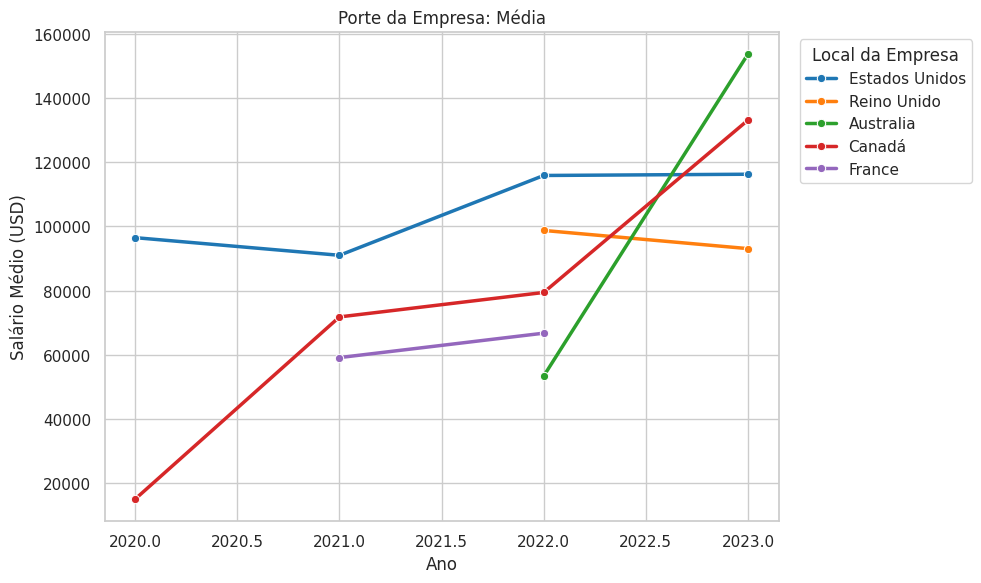

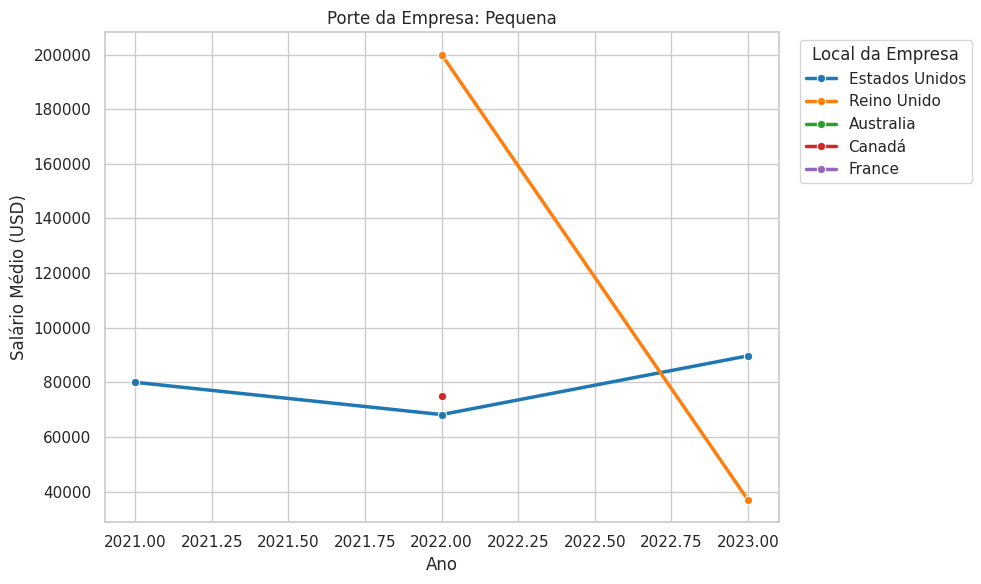

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleciona os 5 países com maior salário médio
top5 = (
    salario_pais_porte_ano
    .groupby("local_empresa")["salario_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Define uma paleta fixa para manter consistência entre os gráficos
palette = {
    top5[0]: "#1f77b4",
    top5[1]: "#ff7f0e",
    top5[2]: "#2ca02c",
    top5[3]: "#d62728",
    top5[4]: "#9467bd"
}

# Gera um gráfico separado para cada porte de empresa
for porte in salario_pais_porte_ano["porte_empresa"].unique():

    df_filtrado = salario_pais_porte_ano[
        (salario_pais_porte_ano["porte_empresa"] == porte) &
        (salario_pais_porte_ano["local_empresa"].isin(top5))
    ]

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df_filtrado,
        x="ano",
        y="salario_usd",
        hue="local_empresa",
        hue_order=top5,
        palette=palette,
        marker="o",
        linewidth=2.5
    )

    plt.title(f"Porte da Empresa: {porte}")
    plt.xlabel("Ano")
    plt.ylabel("Salário Médio (USD)")
    plt.legend(
        title="Local da Empresa",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

#### 7. Comparação salarial entre nível de experiência e porte da empresa

7.1 Gráfico de Barras Agrupado

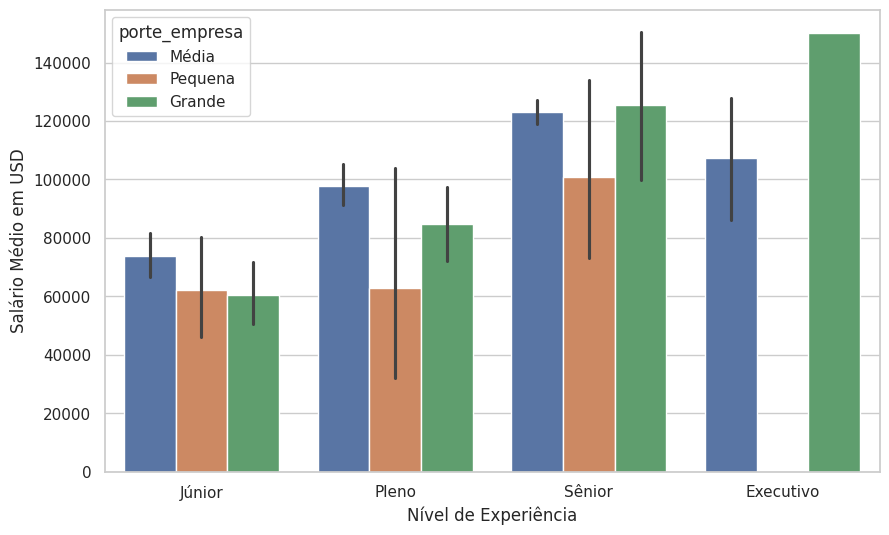

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_da,
    x='nivel_experiencia',
    y='salario_usd',
    hue='porte_empresa',
    estimator=np.mean
)

#plt.title('Comparação Salarial entre Nível de Experiência e Porte da Empresa')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário Médio em USD')

plt.savefig('figura3.png', dpi=300)
plt.show()

##### 7.2. Interpretação dos Resultados

A análise multivariada evidencia que a remuneração dos Data Analysts não depende apenas do país, mas também do porte da empresa e do período analisado.

Observa-se que:

- Países com mercados tecnológicos mais desenvolvidos tendem a apresentar salários mais elevados
- Empresas de grande porte oferecem remunerações superiores de forma consistente
- A evolução ao longo dos anos indica crescimento gradual dos salários em determinados países

Esse comportamento sugere que o mercado de dados é fortemente **influenciado por fatores econômicos e estruturais**, como investimento em tecnologia, maturidade digital e demanda por profissionais qualificados.

#### 8. Média salarial dos níveis de experiência ao longo dos anos (2020 até 2023)

##### 8.1. Agrupando Colunas

In [ ]:
media_salario = (
    df_da
    .groupby(['ano', 'nivel_experiencia'])['salario_usd']
    .mean()
    .reset_index()
)

##### 8.2. Ordena em Colunas

In [ ]:
pivot = media_salario.pivot(
    index='ano',
    columns='nivel_experiencia',
    values='salario_usd'
)

ordem = ['Júnior', 'Pleno', 'Sênior']
pivot = pivot.reindex(columns=ordem)

##### 8.3. Gráfico de Linhas

<Figure size 600x600 with 0 Axes>

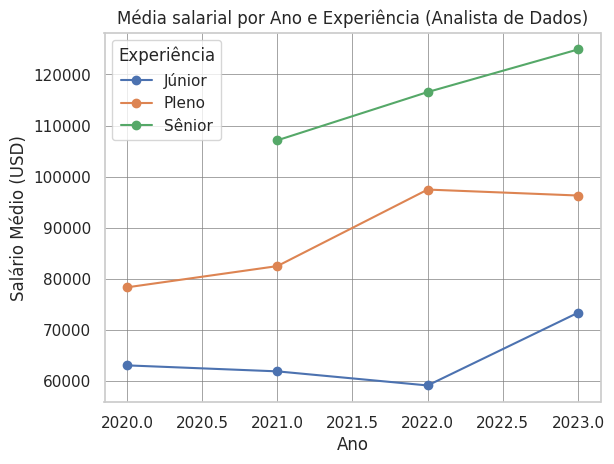

In [ ]:
plt.figure(figsize=(6,6))
pivot.plot(marker='o')

plt.title("Média salarial por Ano e Experiência (Analista de Dados)")
plt.xlabel("Ano")
plt.ylabel("Salário Médio (USD)")
plt.grid(True, color='gray', linewidth=0.5)

plt.legend(title='Experiência')

plt.show()

##### Evolução da média salarial por nível de experiência na Análise de Dados

O gráfico evidencia uma progressão consistente da média salarial conforme o aumento do nível de experiência na profissão de Analista de Dados, reforçando a valorização do conhecimento técnico e da vivência prática no mercado.

Observa-se que profissionais em nível inicial (junior) apresentam as menores médias salariais, o que é esperado devido à menor exposição a projetos complexos e tomada de decisão. No entanto, mesmo nesse estágio, os valores já se mostram competitivos em relação a outras áreas, indicando uma forte demanda por novos talentos.

À medida que o profissional evolui para o nível pleno, há um salto significativo na remuneração. Esse crescimento reflete não apenas o acúmulo de experiência, mas também a capacidade de lidar com maior volume de dados, aplicar análises mais sofisticadas e gerar insights estratégicos para o negócio.

No nível sênior, o gráfico destaca os maiores salários médios, evidenciando o alto valor agregado desses profissionais. Nesse estágio, além do domínio técnico, espera-se uma atuação mais estratégica, com influência direta na tomada de decisão, liderança de projetos e, muitas vezes, mentoria de outros analistas.

Essa progressão salarial demonstra que a área de Análise de Dados possui uma curva de crescimento atrativa e sustentável, incentivando a continuidade do aprendizado e o desenvolvimento de habilidades mais avançadas. Além disso, reforça o papel essencial desses profissionais em um cenário cada vez mais orientado por dados, onde a capacidade de transformar informação em estratégia se torna um diferencial competitivo para as organizações.

#### 9. Crescimento de Analistas de Dados conforme impacto da pandemia


##### 9.1 Porcentagem de Crescimento dos Profissionais

In [ ]:
profissionais_ano = (
    df_da
    .groupby('ano')
    .size()
)

profissionais_ano = profissionais_ano.sort_index()
crescimento = profissionais_ano.pct_change() * 100
print(crescimento)

ano
2020           NaN
2021     86.666667
2022    560.714286
2023    211.891892
dtype: float64


##### 9.2 Gráfico de Linhas

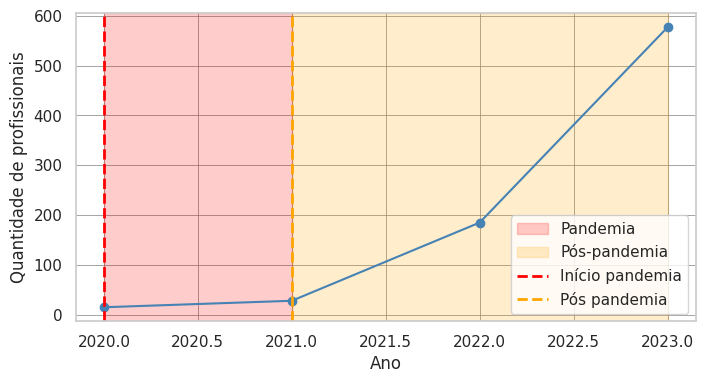

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(profissionais_ano.index, profissionais_ano.values, marker='o', color='steelblue')

#plt.title("Crescimento de Analistas de Dados (2020-2023)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de profissionais")
plt.grid(True, color='gray', linewidth=0.5)

plt.axvspan(2020, 2021, color='red', alpha=0.2, label='Pandemia')
plt.axvspan(2021, 2023, color='orange', alpha=0.2, label='Pós-pandemia')


plt.axvline(x=2020, linestyle='--', color='red',linewidth=2, label='Início pandemia')
plt.axvline(x=2021, linestyle='--', color='orange', linewidth=2, label='Pós pandemia')

plt.legend()
plt.savefig('figura2.png', dpi=300)
plt.show()

#### 10. Salário por experiência ao longo dos anos

##### 10.1 Agrupamento dos Dados

In [ ]:
cargo_salario_ano = df_da.groupby(
    ['ano', 'nivel_experiencia']
)['salario_usd'].median().reset_index()

cargo_salario_ano.head()

,ano,nivel_experiencia,salario_usd
0,2020,Executivo,15000.0
1,2020,Júnior,59949.5
2,2020,Pleno,86000.0
3,2021,Executivo,150000.0
4,2021,Júnior,59102.0


##### 10.2 Gráfico de Linhas

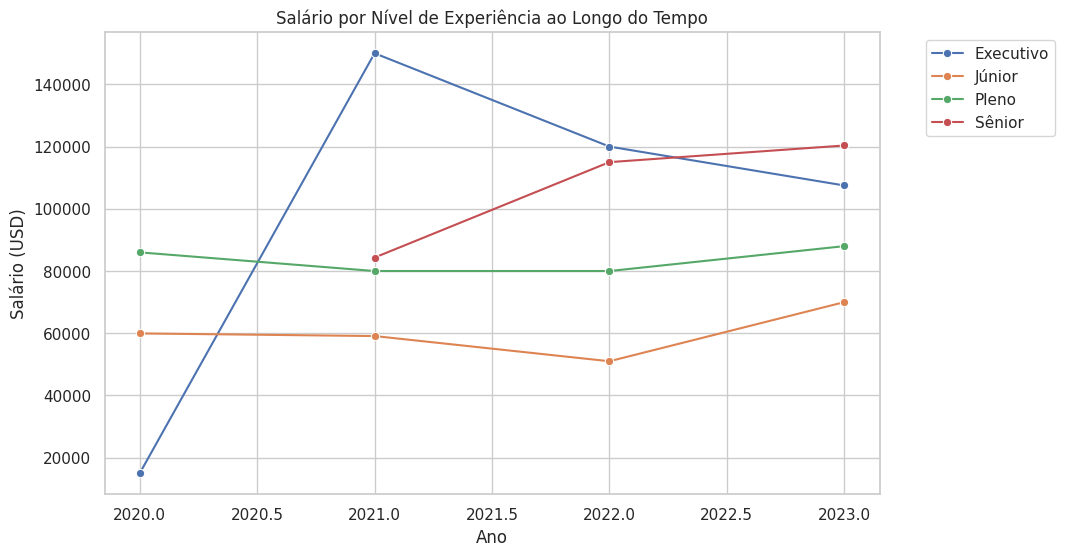

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=cargo_salario_ano,
    x='ano',
    y='salario_usd',
    hue='nivel_experiencia',

    marker='o'
)

plt.title('Salário por Nível de Experiência ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Salário (USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.show()

##### 10.3 Analise de Gráfico: Mudança no mercado.
Ao longo do tempo, os salários na área de dados mostram mudanças importantes. O nível sênior lidera com cerca de USD 120 mil, em crescimento contínuo. Já o nível executivo caiu para $108 mil após pico em 2021, indicando correção de mercado. Os níveis pleno (USD 88 mil) mantêm estabilidade com leve alta, enquanto o júnior (USD 70 mil) apresenta recuperação recente. Há valorização do perfil técnico e aumento dos salários de entrada.

#### 11. Evolução do Modelo de Trabalho (Júnior)

##### 11.1 Filtro de dados

In [ ]:
df_filtrado = df_da[
    (df_da["ano"].isin([2020, 2023])) &
    (df_da["nivel_experiencia"] == "Júnior")
]

In [ ]:
df_group = df_filtrado.groupby(["trabalho_remoto", "ano"]).size().unstack()

##### 11.2 Gráfico Área Empilhada

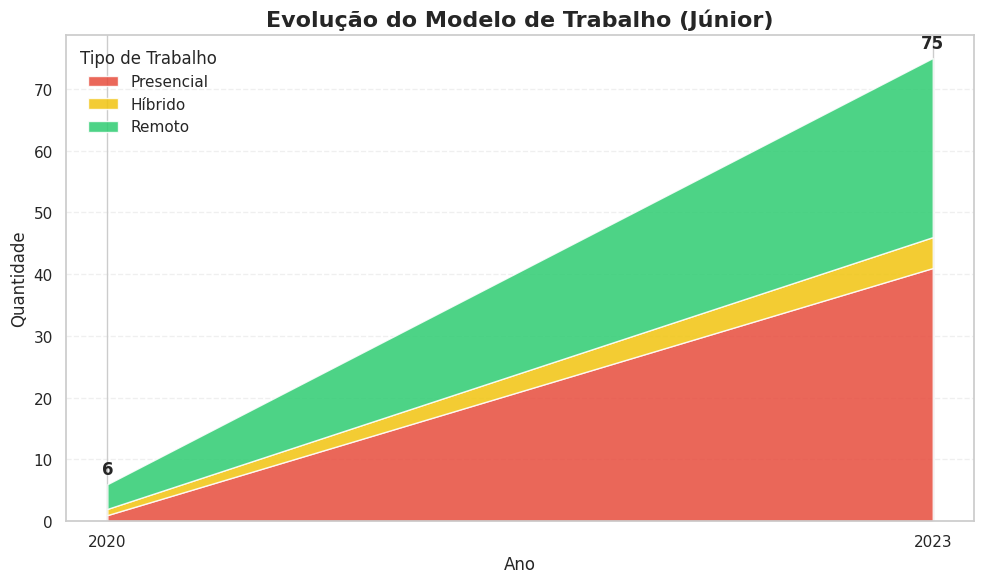

In [ ]:
df_area = df_group.T
df_area = df_area[["Presencial", "Hibrido", "Remoto"]]

anos = df_area.index.astype(int)
presencial = df_area["Presencial"].values
hibrido = df_area["Hibrido"].values
remoto = df_area["Remoto"].values

totais = presencial + hibrido + remoto

plt.figure(figsize=(10,6))

plt.stackplot(
    anos,
    presencial,
    hibrido,
    remoto,
    labels=["Presencial", "Híbrido", "Remoto"],
    colors=["#e74c3c", "#f1c40f", "#2ecc71"],
    alpha=0.85
)

plt.title("Evolução do Modelo de Trabalho (Júnior)", fontsize=16, weight="bold")
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)


plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(loc="upper left", frameon=False, fontsize=11, title="Tipo de Trabalho")

plt.text(anos[0], totais[0] + 1, f"{int(totais[0])}",
         ha='center', va='bottom', fontsize=12, weight='bold')

plt.text(anos[-1], totais[-1] + 1, f"{int(totais[-1])}",
         ha='center', va='bottom', fontsize=12, weight='bold')


plt.xticks(anos)

plt.tight_layout()
plt.show()

##### 11.3 Análise de Gráfico: Crescente no modelo de trabalho ( Junior )

É nítido que a área se desenvolveu muito durante três anos, e tem pontos importantes a ser pauta:
- O modelo remoto é o mais ativo no mercado
- Diversas pessoas se interessou e ingressaram na área
- Indica uma forte expansão do mercado

No geral, os dados revelam não apenas o aumento das oportunidades, mas também uma mudança no perfil do mercado, com maior diversidade nas formas de trabalho ao longo do tempo.

#### 12. Mapa de distribuição global de média de salário

##### 12.1 Instalação do PyCountry

In [ ]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 73.6 MB/s eta 0:00:00


##### 12.2 Mapa Coroplético

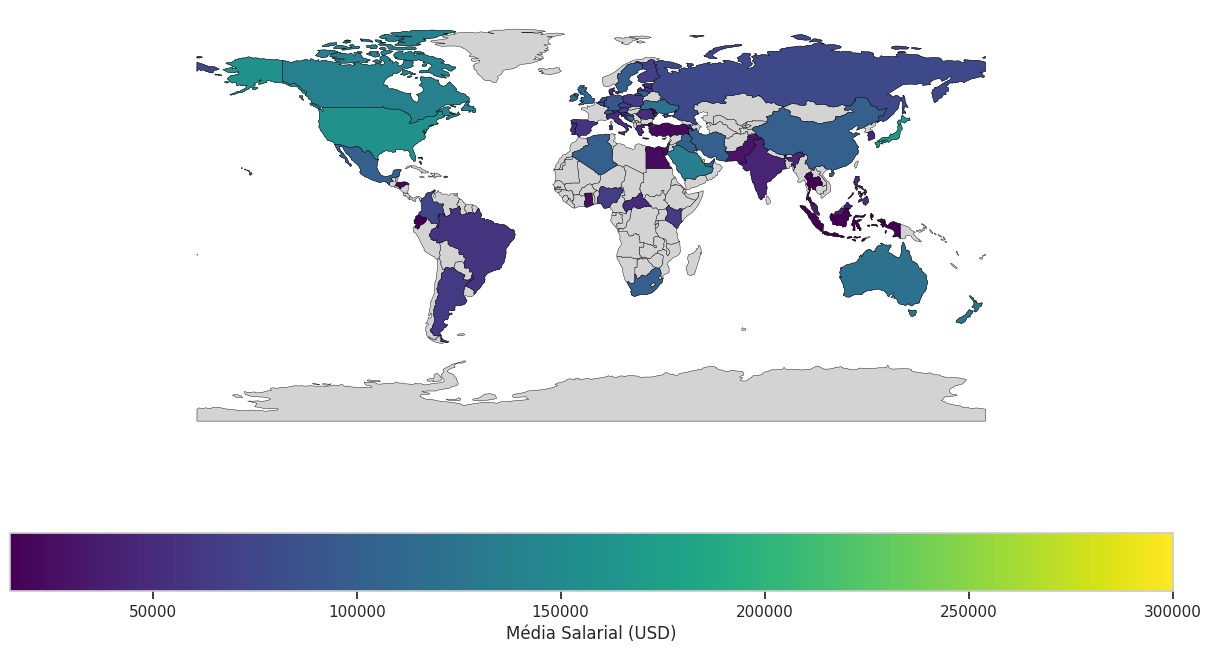

In [ ]:
import geopandas as gpd
import pycountry

salary_country = df.groupby('company_location')['salary_in_usd'].mean().reset_index()

def get_iso_alpha_2(country_name):
    try:
        if country_name == 'United States': return 'US'
        elif country_name == 'United Kingdom': return 'GB'
        elif country_name == 'Russia': return 'RU'
        elif country_name == 'Central African Republic': return 'CF'
        elif country_name == 'American Samoa': return 'AS'
        elif country_name == 'Luxembourg': return 'LU'
        elif country_name == 'Slovenia': return 'SI'
        elif country_name == 'Gibraltar': return 'GI'
        elif country_name == 'Honduras': return 'HN'
        elif country_name == 'Croatia': return 'HR'
        elif country_name == 'Ghana': return 'GH'
        elif country_name == 'Saudi Arabia': return 'SA'
        elif country_name == 'Colombia': return 'CO'
        elif country_name == 'Philippines': return 'PH'
        elif country_name == 'Argentina': return 'AR'
        elif country_name == 'Singapore': return 'SG'
        elif country_name == 'Indonesia': return 'ID'
        elif country_name == 'Greece': return 'GR'
        elif country_name == 'Denmark': return 'DK'
        elif country_name == 'Poland': return 'PL'
        elif country_name == 'Netherlands': return 'NL'
        elif country_name == 'Portugal': return 'PT'
        elif country_name == 'Germany': return 'DE'
        elif country_name == 'Estonia': return 'EE'
        elif country_name == 'Kenya': return 'KE'
        elif country_name == 'Nigeria': return 'NG'
        elif country_name == 'Australia': return 'AU'
        elif country_name == 'Spain': return 'ES'
        elif country_name == 'India': return 'IN'
        elif country_name == 'France': return 'FR'
        elif country_name == 'Canada': return 'CA'
        elif country_name == 'Ukraine': return 'UA'
        elif country_name == 'Turkey': return 'TR'
        elif country_name == 'United Arab Emirates': return 'AE'
        elif country_name == 'Algeria': return 'DZ'
        elif country_name == 'Armenia': return 'AM'
        elif country_name == 'Andorra': return 'AD'
        elif country_name == 'Mexico': return 'MX'
        elif country_name == 'Finland': return 'FI'
        elif country_name == 'Israel': return 'IL'
        elif country_name == 'Japan': return 'JP'
        elif country_name == 'Malaysia': return 'MY'
        elif country_name == 'New Zealand': return 'NZ'
        elif country_name == 'Norway': return 'NO'
        elif country_name == 'South Africa': return 'ZA'
        elif country_name == 'South Korea': return 'KR'
        elif country_name == 'Sweden': return 'SE'
        elif country_name == 'Vietnam': return 'VN'
        else:
            country = pycountry.countries.search_fuzzy(country_name)
            if country:
                return country[0].alpha_2
            else:
                return None
    except LookupError:
        return None

salary_country['iso_a2'] = salary_country['company_location'].apply(get_iso_alpha_2)
salary_country = salary_country.dropna(subset=['iso_a2'])

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

mapa = world.merge(
    salary_country,
    left_on='ISO_A2',
    right_on='iso_a2',
    how='left'
)

fig, ax = plt.subplots(figsize=(15, 8))

mapa.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.3)

mapa.dropna(subset=['salary_in_usd']).plot(
    column='salary_in_usd',
    cmap='viridis',
    legend=True,
    legend_kwds={'label': "Média Salarial (USD)", 'orientation': "horizontal"},
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)

#ax.set_title('Média Salarial por País (Data Jobs)', fontsize=15)
ax.axis('off')

plt.savefig('figura1.png', dpi=300)

plt.show()


A análise da distribuição salarial global na área de dados, em USD, revela diferenças significativas entre regiões, refletindo o nível de maturidade econômica e tecnológica de cada mercado.

Os países foram agrupados em três categorias:

- Mercados consolidados (USD 150k–220k+), como EUA, Canadá e Austrália, com os maiores salários e alta demanda por profissionais experientes.
- Mercados em desenvolvimento (USD 80k–140k), como Europa Ocidental e Japão, com remunerações estáveis, porém inferiores às da América do Norte.
- Mercados emergentes (abaixo de USD 75k), incluindo Brasil, Índia e Sudeste Asiático, onde os salários são impactados por fatores econômicos e cambiais.

Observa-se uma forte disparidade regional, com destaque para a dominância da América do Norte e Oceania em termos salariais. Apesar de existirem salários muito altos (até USD 300k), a maior concentração ocorre entre USD 150k e USD 180k, sendo valores acima disso mais raros e associados a cargos de alta senioridade.